In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
pic = cv2.imread("/home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/data/photos/pushup/correct/pushp.jpg")

In [8]:
gray = cv2.cvtColor(pic, cv2.COLOR_BGR2GRAY)    
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(blurred)
edges = cv2.Canny(enhanced, threshold1=50, threshold2=150)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Close small gaps in edges
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# Remove small noise
cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

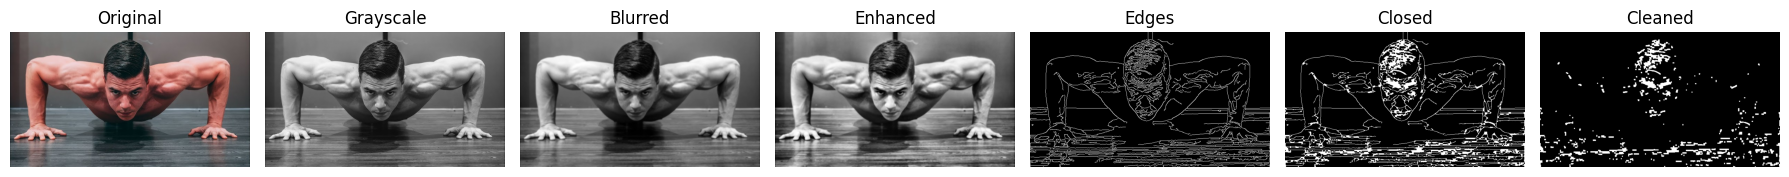

In [23]:
titles = ["Original", "Grayscale", "Blurred", "Enhanced", "Edges", "Closed", "Cleaned"]
images = [
    cv2.cvtColor(pic, cv2.COLOR_BGR2RGB),
    gray, blurred, enhanced, edges, closed, cleaned
]

plt.figure(figsize=(18, 7))
for i, (title, img) in enumerate(zip(titles, images)):
    plt.subplot(1, 7, i + 1)
    plt.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [2]:
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import cv2


def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

In [3]:
model_path = '/home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/models/mediapipe/pose_landmarker_lite.task'

In [ ]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file("/home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/data/photos/pushup/correct/pushup2.png")
print(image.numpy_view().shape)
# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
cv2.imshow("Pose Landmarks", cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR))
cv2.waitKey(0)
cv2.destroyAllWindows()

I0000 00:00:1777831965.748137   33254 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777831965.756395   33270 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
W0000 00:00:1777831966.005406   33257 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777831966.134301   33266 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


(720, 1280, 4)


AttributeError: 'PoseLandmarkerResult' object has no attribute 'numpy_view'

: 

In [8]:
detection_result

PoseLandmarkerResult(pose_landmarks=[], pose_world_landmarks=[], segmentation_masks=None)

In [7]:
segmentation_mask = detection_result.segmentation_masks[0].numpy_view()
segmentation_mask = np.squeeze(segmentation_mask)

# Convert to 3‑channel uint8 image for visualization.
visualized_mask = (segmentation_mask * 255).astype(np.uint8)
visualized_mask = np.stack([visualized_mask]*3, axis=-1)



TypeError: 'NoneType' object is not subscriptable

In [14]:
# Step 1 - Download model (run once)
import urllib.request
import os

model_path = "/home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/models/mediapipe/pose_landmarker_heavy.task"

if not os.path.exists(model_path):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task",
        model_path
    )
    print("Model downloaded!")
else:
    print("Model already exists!")

Model downloaded!


In [32]:
im_path = "/home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/data/photos/pushup/correct/pushup2.png"

In [35]:
im = cv2.imread(im_path)
print(im.shape)

(720, 1280, 3)


In [20]:
# Step 2 - Run detection
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

detector = vision.PoseLandmarker.create_from_options(options)

image = mp.Image.create_from_file('image.jpg')
result = detector.detect(image)

print(f"Landmarks found: {len(result.pose_landmarks)}")

I0000 00:00:1777831088.424781   31590 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777831088.432423   31606 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) UHD Graphics (CML GT2)
W0000 00:00:1777831088.675490   31594 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777831088.807967   31603 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Landmarks found: 1


In [ ]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
PoseLandmarkerResult = mp.tasks.vision.PoseLandmarkerResult
VisionRunningMode = mp.tasks.vision.RunningMode

# Create a pose landmarker instance with the live stream mode:
def print_result(result: PoseLandmarkerResult, output_image: mp.Image, timestamp_ms: int):
    print('pose landmarker result: {}'.format(result))

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=VisionRunningMode.LIVE_STREAM,
    result_callback=print_result)

with PoseLandmarker.create_from_options(options) as landmarker:

In [2]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()
while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    # Our operations on the frame come here
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Display the resulting frame
    cv2.imshow('frame', gray)
    if cv2.waitKey(1) == ord('q'):
        break

# When everything done, release the capture
cap.release()
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/.venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/.venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/.venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rodrigo-pinto22/Documents/MCD/Ano_1/Semestre_2/CV/CV_Project/repcounter/.

In [7]:
cap = cv2.VideoCapture(0)  # 0 = câmara principal do laptop

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Erro ao capturar frame")
        break

    # --- PREPROCESSING (#03) ---
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)

    # --- EDGE DETECTION (#04) ---
    edges = cv2.Canny(enhanced, 50, 150)

    # --- MORPHOLOGICAL OPS (#05) ---
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.dilate(edges, kernel, iterations=1)

    # --- MOSTRAR RESULTADOS ---
    cv2.imshow("Original", frame)
    cv2.imshow("Edges", cleaned)

    # Sair com 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [24]:
def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 50, 150)
    
    # Dilatar para fechar gaps nos contornos
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    
    # Encontrar contornos e preencher
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Criar máscara vazia e preencher apenas os contornos maiores
    mask = np.zeros_like(dilated)
    for cnt in contours:
        if cv2.contourArea(cnt) > 5000:  # ignora ruído pequeno
            cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    
    # Fechar buracos que ficaram dentro da mancha
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (30, 30))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    
    return filled

In [45]:
def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 80, 180)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated = cv2.dilate(edges, kernel, iterations=2)
    return dilated

In [31]:
def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Blur moderado — a imagem já é limpa
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    
    # CLAHE suave — o contraste já é bom
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    
    # Canny — thresholds mais altos porque o fundo é limpo
    edges = cv2.Canny(enhanced, 80, 180)
    
    # Dilatar para fechar contornos
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    
    # Pegar nos maiores contornos
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
    
    mask = np.zeros_like(dilated)
    for cnt in contours:
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    
    # Fechar buracos internos
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    
    return filled

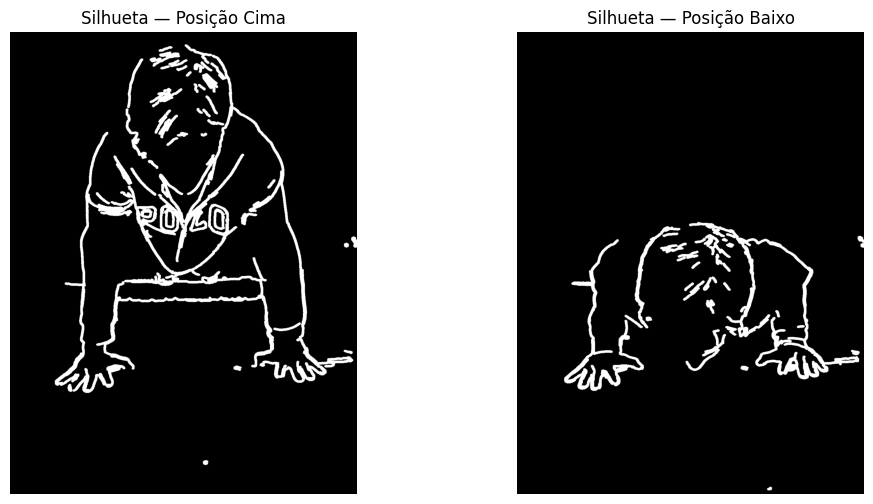

In [46]:
up = extract_silhouette("../data/photos/pushup/correct/up_2.jpeg")
down = extract_silhouette("../data/photos/pushup/correct/down_2.jpeg")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(up, cmap="gray")
axes[0].set_title("Silhueta — Posição Cima")
axes[0].axis("off")
axes[1].imshow(down, cmap="gray")
axes[1].set_title("Silhueta — Posição Baixo")
axes[1].axis("off")
plt.show()

In [11]:
def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 100, 200)
    
    # Dilatar bastante para fechar os gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    
    # Encontrar contorno maior (o teu corpo)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mask = np.zeros_like(dilated)
    
    # Ordenar por área e pegar nos maiores
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:3]
    for cnt in contours:
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    
    # Fechar buracos internos (óculos, t-shirt, etc.)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    
    return filled

In [64]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

# MOG2 — algoritmo de background subtraction
backSub = cv2.createBackgroundSubtractorMOG2(
    history=500,        # frames para aprender o background
    varThreshold=50,    # sensibilidade
    detectShadows=False # ignora sombras
)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocessing (#03)
    blurred = cv2.GaussianBlur(frame, (15, 15), 0)

    # Background subtraction
    fg_mask = backSub.apply(blurred)

    # Morfologia (#05) — limpar ruído
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    cleaned = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    # Mostrar
    cv2.imshow("Original", frame)
    cv2.imshow("Silhueta", cleaned)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

[ WARN:0@7246.955] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[video4linux2,v4l2 @ 0x14451440] ioctl(VIDIOC_G_INPUT): Inappropriate ioctl for device
[ERROR:0@7246.957] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


---

In [63]:
import cv2
import numpy as np

# ─── FUNÇÕES ───────────────────────────────────────────
def resize_with_padding(mask, target_w, target_h):
    h, w = mask.shape
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    resized = cv2.resize(mask, (new_w, new_h))
    
    # Criar fundo preto do tamanho do frame
    padded = np.zeros((target_h, target_w), dtype=np.uint8)
    
    # Centrar a máscara
    x = (target_w - new_w) // 2
    y = (target_h - new_h) // 2
    padded[y:y+new_h, x:x+new_w] = resized
    
    return padded

def extract_silhouette(image_path, frame_size=None):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 80, 180)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
    mask = np.zeros_like(dilated)
    for cnt in contours:
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    if frame_size:
        filled = cv2.resize(filled, frame_size)
    return filled

def extract_user_mask(frame, background):
    diff = cv2.absdiff(
        cv2.cvtColor(background, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    )
    _, mask = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def calculate_overlap(reference_mask, user_mask):
    intersection = cv2.bitwise_and(reference_mask, user_mask)
    ref_area = np.sum(reference_mask > 0)
    if ref_area == 0:
        return 0.0
    return np.sum(intersection > 0) / ref_area

# ─── SETUP ─────────────────────────────────────────────

cap = cv2.VideoCapture(0)

# Capturar background
print("Fica fora do frame... a capturar background em 3 segundos")
cv2.waitKey(3000)
ret, background = cap.read()
print("Background capturado!")

# Extrair silhuetas de referência
frame_size = (background.shape[1], background.shape[0])
mask_up   = extract_silhouette("../data/photos/pushup/correct/up_2.jpeg", frame_size)
mask_down = extract_silhouette("../data/photos/pushup/correct/down_2.jpeg", frame_size)
mask_up_resized   = resize_with_padding(mask_up,   frame.shape[1], frame.shape[0])
mask_down_resized = resize_with_padding(mask_down, frame.shape[1], frame.shape[0])
print("Silhuetas de referência carregadas!")

# ─── LOOP PRINCIPAL ────────────────────────────────────

state = "UP"
reps = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    user_mask    = extract_user_mask(frame, background)
    overlap_up   = calculate_overlap(mask_up, user_mask)
    overlap_down = calculate_overlap(mask_down, user_mask)

    if overlap_up > 0.85 and state == "DOWN":
        state = "UP"
        reps += 1
    elif overlap_down > 0.85 and state == "UP":
        state = "DOWN"

    overlay = frame.copy()
    if state == "UP":
        overlay[mask_up > 0] = [0, 255, 0]
    else:
        overlay[mask_down > 0] = [0, 0, 255]

    result = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)

    cv2.putText(result, f"Reps: {reps}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.putText(result, f"Estado: {state}", (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(result, f"Overlap UP: {overlap_up:.2f}", (10, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(result, f"Overlap DOWN: {overlap_down:.2f}", (10, 180),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    cv2.imshow("RepCounter", result)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Fica fora do frame... a capturar background em 3 segundos
Background capturado!
Silhuetas de referência carregadas!


KeyboardInterrupt: 

In [67]:
# Mostrar frame com ROI antes de começar
def calibrate(cap, mask_up):
    print("CALIBRAÇÃO — posiciona-te dentro da caixa verde")
    
    while True:
        ret, frame = cap.read()
        
        # Desenhar caixa de referência
        h, w = frame.shape[:2]
        
        # ROI — centro do frame
        x1, y1 = w//4, h//4
        x2, y2 = 3*w//4, 3*h//4
        
        cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(frame, "Posiciona-te aqui e prime SPACE", 
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
                    0.7, (0,255,0), 2)
        
        cv2.imshow("Calibração", frame)
        
        key = cv2.waitKey(1)
        if key == ord(' '):  # SPACE para confirmar
            cv2.destroyWindow("Calibração")
            return (x1, y1, x2, y2)

---

In [3]:
import cv2
import numpy as np

# ─── FUNÇÕES ───────────────────────────────────────────

def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 80, 180)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
    mask = np.zeros_like(dilated)
    for cnt in contours:
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    return filled

def resize_with_padding(mask, target_w, target_h):
    h, w = mask.shape
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(mask, (new_w, new_h))
    padded = np.zeros((target_h, target_w), dtype=np.uint8)
    x = (target_w - new_w) // 2
    y = (target_h - new_h) // 2
    padded[y:y+new_h, x:x+new_w] = resized
    return padded

def extract_user_mask(frame, background):
    diff = cv2.absdiff(
        cv2.cvtColor(background, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    )
    _, mask = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def calculate_overlap(reference_mask, user_mask):
    intersection = cv2.bitwise_and(reference_mask, user_mask)
    ref_area = np.sum(reference_mask > 0)
    if ref_area == 0:
        return 0.0
    return np.sum(intersection > 0) / ref_area

def calibrate(cap):
    print("CALIBRAÇÃO — posiciona-te dentro da caixa e prime SPACE")
    while True:
        ret, frame = cap.read()
        if not ret:
            return None
        h, w = frame.shape[:2]
        
        # Era w//4 e h//4 — muito pequeno
        # Agora ocupa 80% do frame
        x1, y1 = int(w * 0.02), int(h * 0.02)
        x2, y2 = int(w * 0.98), int(h * 0.98)
        
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, "Prima SPACE para confirmar ou Q para sair",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.imshow("RepCounter", frame)
        key = cv2.waitKey(1)
        if key == ord(' '):
            return (x1, y1, x2, y2)
        elif key == ord('q'):
            return None

# ─── SETUP ─────────────────────────────────────────────

# Carregar silhuetas de referência
mask_up   = extract_silhouette("../data/photos/pushup/correct/up_2.jpeg")
mask_down = extract_silhouette("../data/photos/pushup/correct/down_2.jpeg")

cap = cv2.VideoCapture(0)

# Passo 1 — Calibração
roi = calibrate(cap)
if roi is None:
    print("Cancelado.")
    cap.release()
    cv2.destroyAllWindows()
    exit()

x1, y1, x2, y2 = roi
roi_w = x2 - x1
roi_h = y2 - y1

# Redimensionar máscaras para o tamanho da ROI
mask_up_roi   = resize_with_padding(mask_up,   roi_w, roi_h)
mask_down_roi = resize_with_padding(mask_down, roi_w, roi_h)

# Passo 2 — Capturar background
print("Fica fora do frame... 3 segundos")
cv2.waitKey(3000)
ret, background = cap.read()
print("Background capturado! Começa o exercício.")

# ─── LOOP PRINCIPAL ────────────────────────────────────

state = "UP"
reps  = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Recortar ROI
    frame_roi = frame[y1:y2, x1:x2]
    bg_roi    = background[y1:y2, x1:x2]

    # Silhueta do utilizador
    user_mask = extract_user_mask(frame_roi, bg_roi)

    # Sobreposição
    overlap_up   = calculate_overlap(mask_up_roi, user_mask)
    overlap_down = calculate_overlap(mask_down_roi, user_mask)

    # Lógica da rep
    if overlap_up > 0.75 and state == "DOWN":
        state = "UP"
        reps += 1
    elif overlap_down > 0.75 and state == "UP":
        state = "DOWN"

    # Overlay visual na ROI
    overlay = frame.copy()
    if state == "UP":
        overlay[y1:y2, x1:x2][mask_up_roi > 0] = [0, 255, 0]
    else:
        overlay[y1:y2, x1:x2][mask_down_roi > 0] = [0, 0, 255]

    result = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)

    # Desenhar ROI
    cv2.rectangle(result, (x1, y1), (x2, y2), (255, 255, 0), 2)

    # Texto
    cv2.putText(result, f"Reps: {reps}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.putText(result, f"Estado: {state}", (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(result, f"Overlap UP: {overlap_up:.2f}", (10, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(result, f"Overlap DOWN: {overlap_down:.2f}", (10, 180),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    cv2.imshow("RepCounter", result)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

CALIBRAÇÃO — posiciona-te dentro da caixa e prime SPACE
Fica fora do frame... 3 segundos
Background capturado! Começa o exercício.


In [18]:
import cv2
import numpy as np

# ─── FUNÇÕES ───────────────────────────────────────────

def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 80, 180)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
    mask = np.zeros_like(dilated)
    for cnt in contours:
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    return filled

def resize_with_padding(mask, target_w, target_h, align="bottom"):
    h, w = mask.shape
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(mask, (new_w, new_h))
    padded = np.zeros((target_h, target_w), dtype=np.uint8)
    
    x = (target_w - new_w) // 2  # centrado horizontalmente
    
    if align == "bottom":
        y = target_h - new_h      # colado à base ← novo
    elif align == "top":
        y = 0
    else:
        y = (target_h - new_h) // 2  # centrado (anterior)
    
    padded[y:y+new_h, x:x+new_w] = resized
    return padded

def extract_user_mask(frame, background):
    diff = cv2.absdiff(
        cv2.cvtColor(background, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    )
    _, mask = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def calculate_overlap(reference_mask, user_mask):
    intersection = cv2.bitwise_and(reference_mask, user_mask)
    
    # Usar a união em vez da referência
    union = cv2.bitwise_or(reference_mask, user_mask)
    union_area = np.sum(union > 0)
    
    if union_area == 0:
        return 0.0
    
    # IoU — Intersection over Union
    return np.sum(intersection > 0) / union_area

def calibrate(cap):
    print("CALIBRAÇÃO — posiciona-te dentro da caixa e prime SPACE")
    while True:
        ret,    frame = cap.read()
        if not ret:
            return None
        h, w = frame.shape[:2]
        x1, y1 = int(w * 0.02), int(h * 0.02)
        x2, y2 = int(w * 0.98), int(h * 0.98)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, "Prima SPACE para confirmar ou Q para sair",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.imshow("RepCounter", frame)
        key = cv2.waitKey(1)
        if key == ord(' '):
            return (x1, y1, x2, y2)
        elif key == ord('q'):
            return None

# ─── PARÂMETROS ────────────────────────────────────────

OVERLAP_THRESHOLD      = 0.35
STABLE_FRAMES_REQUIRED = 20  # ~0.5s a 30fps

# ─── SETUP ─────────────────────────────────────────────

mask_up   = extract_silhouette("../data/photos/pushup/correct/up_3.jpeg")
mask_down = extract_silhouette("../data/photos/pushup/correct/down_3.jpeg")

cap = cv2.VideoCapture(0)

roi = calibrate(cap)
if roi is None:
    print("Cancelado.")
    cap.release()
    cv2.destroyAllWindows()
    exit()

x1, y1, x2, y2 = roi
roi_w = x2 - x1
roi_h = y2 - y1

mask_up_roi   = resize_with_padding(mask_up,   roi_w, roi_h, align="bottom")
mask_down_roi = resize_with_padding(mask_down, roi_w, roi_h, align="bottom")


print("Fica fora do frame... 3 segundos")
cv2.waitKey(3000)
ret, background = cap.read()
print("Background capturado! Começa o exercício.")

# ─── LOOP PRINCIPAL ────────────────────────────────────

state = "UP"
reps  = 0

stable_up_count   = 0
stable_down_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_roi = frame[y1:y2, x1:x2]
    bg_roi    = background[y1:y2, x1:x2]

    user_mask    = extract_user_mask(frame_roi, bg_roi)
    overlap_up   = calculate_overlap(mask_up_roi, user_mask)
    overlap_down = calculate_overlap(mask_down_roi, user_mask)

    # ─── Estabilidade ──────────────────────────────────
    if overlap_up > OVERLAP_THRESHOLD:
        stable_up_count += 1
    else:
        stable_up_count = 0

    if overlap_down > OVERLAP_THRESHOLD:
        stable_down_count += 1
    else:
        stable_down_count = 0

    # ─── Lógica da rep ─────────────────────────────────
    if stable_up_count >= STABLE_FRAMES_REQUIRED and state == "DOWN":
        state = "UP"
        reps += 1
        stable_up_count = 0

    elif stable_down_count >= STABLE_FRAMES_REQUIRED and state == "UP":
        state = "DOWN"
        stable_down_count = 0

    # ─── Overlay visual ────────────────────────────────
    overlay = frame.copy()
    if state == "UP":
        overlay[y1:y2, x1:x2][mask_up_roi > 0] = [0, 255, 0]
    else:
        overlay[y1:y2, x1:x2][mask_down_roi > 0] = [0, 0, 255]

    result = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)

    cv2.rectangle(result, (x1, y1), (x2, y2), (255, 255, 0), 2)

    # Barras de progresso
    progress_up   = int((stable_up_count   / STABLE_FRAMES_REQUIRED) * 100)
    progress_down = int((stable_down_count / STABLE_FRAMES_REQUIRED) * 100)

    cv2.putText(result, f"Reps: {reps}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.putText(result, f"Estado: {state}", (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(result, f"Overlap UP:   {overlap_up:.2f}", (10, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(result, f"Overlap DOWN: {overlap_down:.2f}", (10, 180),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(result, f"Estab. UP:   {progress_up}%", (10, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(result, f"Estab. DOWN: {progress_down}%", (10, 240),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    cv2.imshow("RepCounter", result)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

CALIBRAÇÃO — posiciona-te dentro da caixa e prime SPACE
Fica fora do frame... 3 segundos
Background capturado! Começa o exercício.


In [ ]:
import cv2
import numpy as np

# ─── FUNÇÕES ───────────────────────────────────────────

def extract_silhouette(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    edges = cv2.Canny(enhanced, 80, 180)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20, 20))
    dilated = cv2.dilate(edges, kernel, iterations=3)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
    mask = np.zeros_like(dilated)
    for cnt in contours:
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (40, 40))
    filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_large)
    return filled

def resize_with_padding(mask, target_w, target_h, align="bottom"):
    h, w = mask.shape
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(mask, (new_w, new_h))
    padded = np.zeros((target_h, target_w), dtype=np.uint8)
    x = (target_w - new_w) // 2
    if align == "bottom":
        y = target_h - new_h
    elif align == "top":
        y = 0
    else:
        y = (target_h - new_h) // 2
    padded[y:y+new_h, x:x+new_w] = resized
    return padded

def extract_user_mask(frame, background):
    diff = cv2.absdiff(
        cv2.cvtColor(background, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    )
    _, mask = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask

def calculate_overlap(reference_mask, user_mask):
    intersection = cv2.bitwise_and(reference_mask, user_mask)
    union = cv2.bitwise_or(reference_mask, user_mask)
    union_area = np.sum(union > 0)
    if union_area == 0:
        return 0.0
    return np.sum(intersection > 0) / union_area

def calibrate(cap):
    print("CALIBRAÇÃO — posiciona-te dentro da caixa e prime SPACE")
    while True:
        ret, frame = cap.read()
        if not ret:
            return None
        h, w = frame.shape[:2]
        x1, y1 = int(w * 0.02), int(h * 0.02)
        x2, y2 = int(w * 0.98), int(h * 0.98)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, "Prima SPACE para confirmar ou Q para sair",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.imshow("RepCounter", frame)
        key = cv2.waitKey(1)
        if key == ord(' '):
            return (x1, y1, x2, y2)
        elif key == ord('q'):
            return None

# ─── PARÂMETROS ────────────────────────────────────────

OVERLAP_THRESHOLD = 0.5

# ─── SETUP ─────────────────────────────────────────────

mask_up   = extract_silhouette("../data/photos/pushup/correct/up_3.jpeg")
mask_down = extract_silhouette("../data/photos/pushup/correct/down_3.jpeg")

cap = cv2.VideoCapture(0)

roi = calibrate(cap)
if roi is None:
    print("Cancelado.")
    cap.release()
    cv2.destroyAllWindows()
    exit()

x1, y1, x2, y2 = roi
roi_w = x2 - x1
roi_h = y2 - y1

mask_up_roi   = resize_with_padding(mask_up,   roi_w, roi_h, align="bottom")
mask_down_roi = resize_with_padding(mask_down, roi_w, roi_h, align="bottom")

print("Fica fora do frame... 3 segundos")
cv2.waitKey(3000)
ret, background = cap.read()
print("Background capturado! Começa o exercício.")

# ─── LOOP PRINCIPAL ────────────────────────────────────

state = "UP"
reps  = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_roi = frame[y1:y2, x1:x2]
    bg_roi    = background[y1:y2, x1:x2]

    user_mask    = extract_user_mask(frame_roi, bg_roi)
    overlap_up   = calculate_overlap(mask_up_roi, user_mask)
    overlap_down = calculate_overlap(mask_down_roi, user_mask)

    # ─── Lógica da rep ─────────────────────────────────
    if overlap_up > OVERLAP_THRESHOLD and state == "UP":
        state = "DOWN"

    elif overlap_down > OVERLAP_THRESHOLD and state == "DOWN":
        state = "UP"
        reps += 1 

    # ─── Overlay visual ────────────────────────────────
    overlay = frame.copy()
    if state == "UP":
        overlay[y1:y2, x1:x2][mask_up_roi > 0] = [0, 255, 0]
    else:
        overlay[y1:y2, x1:x2][mask_down_roi > 0] = [0, 0, 255]

    result = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)

    cv2.rectangle(result, (x1, y1), (x2, y2), (255, 255, 0), 2)

    cv2.putText(result, f"Reps: {reps}", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.putText(result, f"Estado: {state}", (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(result, f"Overlap UP:   {overlap_up:.2f}", (10, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(result, f"Overlap DOWN: {overlap_down:.2f}", (10, 180),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    cv2.imshow("RepCounter", result)
    cv2.imshow("User Mask", user_mask)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

CALIBRAÇÃO — posiciona-te dentro da caixa e prime SPACE
Fica fora do frame... 3 segundos
Background capturado! Começa o exercício.
